# Augmentacija audio podataka u mašinskom učenju

In [5]:
%pip install librosa audiomentations torch torchaudio numpy matplotlib pandas scikit-learn scipy soundfile "datasets==2.21.0"

Note: you may need to restart the kernel to use updated packages.


## Import

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from pathlib import Path
from datasets import load_dataset
import warnings
from datasets import Audio

warnings.filterwarnings('ignore')
np.random.seed(42)

## Dataset

In [7]:
cache_dir = Path(os.getcwd()) / "data"
cache_dir.mkdir(exist_ok=True)

In [10]:
ds = load_dataset('librispeech_asr', 'clean', split='train.100', cache_dir=cache_dir)
test_ds = load_dataset('librispeech_asr', 'clean', split='test', cache_dir=cache_dir)

ds = ds.cast_column('audio', Audio())
test_ds = test_ds.cast_column('audio', Audio())

## Analiza skupa

In [19]:
def get_metadata(sample):
    audio = sample['audio']
    duration = len(audio['array']) / audio['sampling_rate']
    num_words = len(sample['text'].split())
    num_chars = len(sample['text'])
    return {
        'duration': duration,
        'num_words': num_words,
        'num_chars': num_chars,
        'speaker_id': sample['speaker_id'],
        'chapter_id': sample['chapter_id'],
        'sampling_rate': audio['sampling_rate'],
    }

def plot_panel(ax, data, plot_type='hist', title='', xlabel='', ylabel='',
               color='steelblue', bins=50, show_mean_median=True,
               bar_values=None,
               scatter_y=None,):

    if plot_type == 'hist':
        ax.hist(data, bins=bins, color=color, alpha=0.85)
        if show_mean_median:
            mean_val = np.mean(data)
            median_val = np.median(data)
            ax.axvline(mean_val, color='black', linestyle='--', label=f"Mean: {mean_val:.1f}")
            ax.axvline(median_val, color='red', linestyle='--', label=f"Median: {median_val:.1f}")
            ax.legend()

    elif plot_type == 'bar':
        ax.bar(range(len(bar_values)), bar_values, color=color, alpha=0.85)
        ax.set_xticks([])

    elif plot_type == 'scatter':
        ax.scatter(data, scatter_y, alpha=0.05, color=color)

    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)


In [12]:
train_meta = ds.map(get_metadata, remove_columns=ds.column_names)
train_df = train_meta.to_pandas()

test_meta = test_ds.map(get_metadata, remove_columns=test_ds.column_names)
test_df = test_meta.to_pandas()

display(train_df.describe().round(2))

Map: 100%|██████████| 2620/2620 [00:04<00:00, 643.74 examples/s]


,speaker_id,chapter_id,duration,num_words,num_chars,sampling_rate
count,28539.00,28539.00,28539.00,28539.00,28539.00,28539.0
mean,3807.55,116990.73,12.69,34.69,184.65,16000.0
std,2780.34,82998.82,3.57,11.29,58.65,0.0
min,19.00,198.00,1.41,2.00,8.00,16000.0
25%,1116.00,41615.00,11.62,29.00,157.00,16000.0
50%,3664.00,123523.00,14.00,36.00,195.00,16000.0
75%,6181.00,152139.00,15.16,42.00,225.00,16000.0
max,8975.00,305213.00,24.52,75.00,398.00,16000.0


In [13]:
print("=" * 50)
print("TRAIN SPLIT")
print("=" * 50)
print(f"Broj uzoraka:       {len(train_df)}")
print(f"Broj govornika:     {train_df['speaker_id'].nunique()}")
print(f"Broj poglavlja:     {train_df['chapter_id'].nunique()}")
print(f"Ukupno trajanje:    {train_df['duration'].sum() / 3600:.2f} h")
print(f"Prosečno trajanje:  {train_df['duration'].mean():.2f} s")
print(f"Medijana trajanja:  {train_df['duration'].median():.2f} s")
print(f"Min / Max:          {train_df['duration'].min():.2f}s / {train_df['duration'].max():.2f}s")
print(f"Sampling rate:      {train_df['sampling_rate'].unique()} Hz")

print("\n" + "=" * 50)
print("TEST SPLIT")
print("=" * 50)
print(f"Broj uzoraka:       {len(test_df)}")
print(f"Broj govornika:     {test_df['speaker_id'].nunique()}")
print(f"Ukupno trajanje:    {test_df['duration'].sum() / 3600:.2f} h")
print(f"Prosečno trajanje:  {test_df['duration'].mean():.2f} s")

TRAIN SPLIT
Broj uzoraka:       28539
Broj govornika:     251
Broj poglavlja:     585
Ukupno trajanje:    100.59 h
Prosečno trajanje:  12.69 s
Medijana trajanja:  13.99 s
Min / Max:          1.41s / 24.52s
Sampling rate:      [16000] Hz

TEST SPLIT
Broj uzoraka:       2620
Broj govornika:     40
Ukupno trajanje:    5.40 h
Prosečno trajanje:  7.42 s


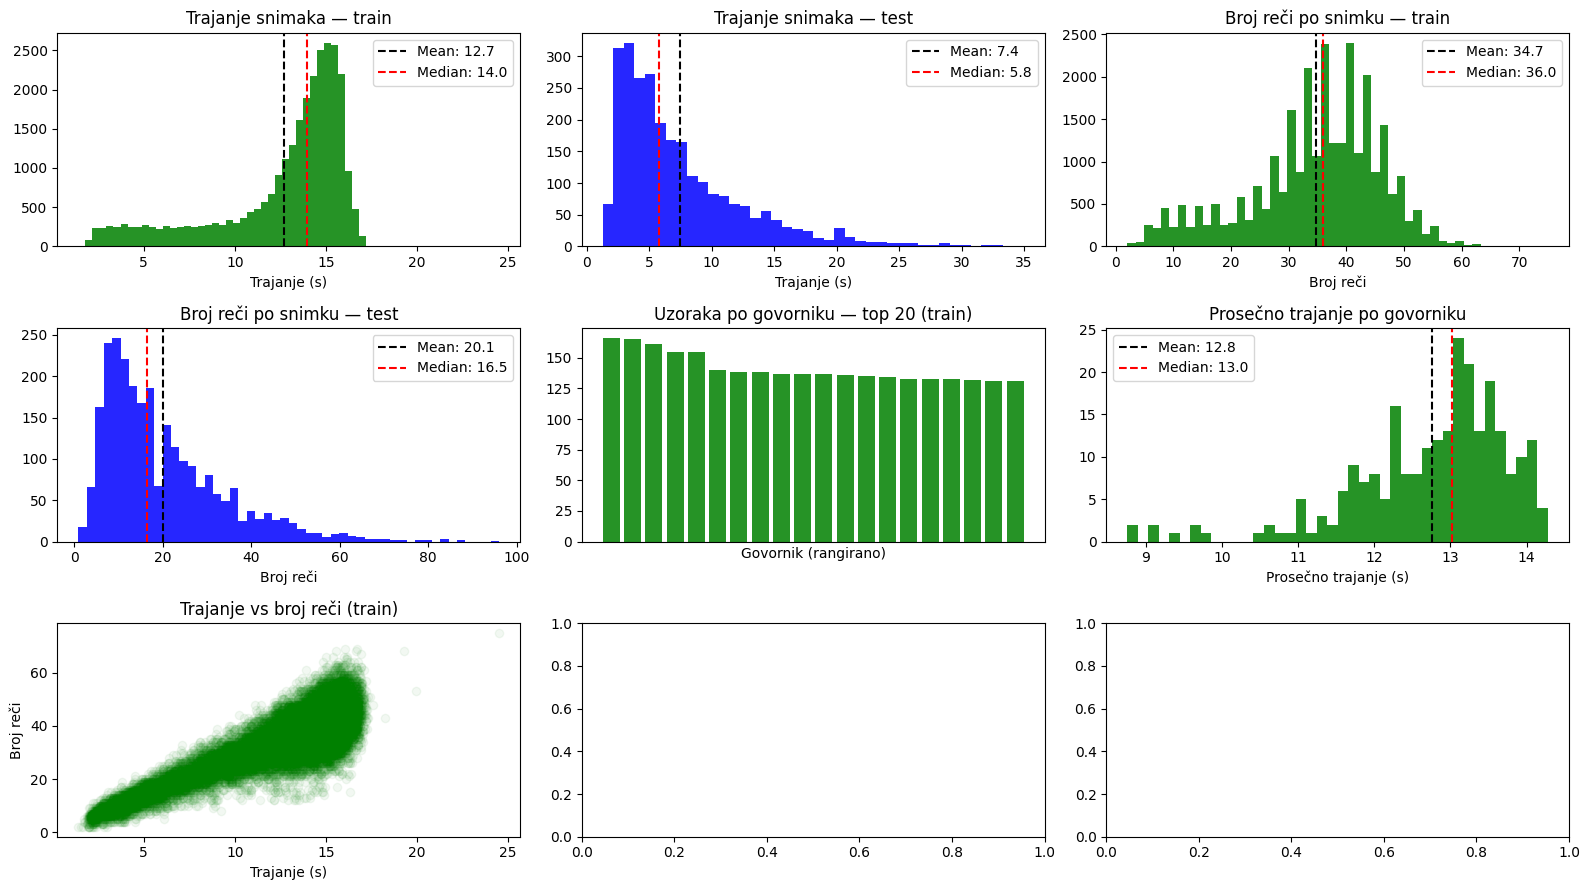

In [22]:
fig, axes = plt.subplots(3, 3, figsize=(16, 9))
train_color = 'green'
test_color = 'blue'
plot_panel(axes[0, 0], train_df['duration'],
           plot_type='hist', bins=60, color=train_color,
           title="Trajanje snimaka — train", xlabel="Trajanje (s)")

plot_panel(axes[0, 1], test_df['duration'],
           plot_type='hist', bins=40, color=test_color,
           title="Trajanje snimaka — test", xlabel="Trajanje (s)")

plot_panel(axes[0, 2], train_df['num_words'],
           plot_type='hist', bins=50, color=train_color,
           title="Broj reči po snimku — train", xlabel="Broj reči")

plot_panel(axes[1, 0], test_df['num_words'],
           plot_type='hist', bins=50, color=test_color,
           title="Broj reči po snimku — test", xlabel="Broj reči")

plot_panel(axes[1, 1], data=None,
           plot_type='bar', color=train_color,
           bar_values=train_df['speaker_id'].value_counts().head(20).values,
           title="Uzoraka po govorniku — top 20 (train)",
           xlabel="Govornik (rangirano)", show_mean_median=False)

plot_panel(axes[1, 2], train_df.groupby('speaker_id')['duration'].mean(),
           plot_type='hist', bins=40, color=train_color,
           title="Prosečno trajanje po govorniku", xlabel="Prosečno trajanje (s)")

corr = train_df[['duration', 'num_words']].corr().iloc[0, 1]
plot_panel(axes[2, 0], train_df['duration'],
           plot_type='scatter', color=train_color,
           scatter_y=train_df['num_words'],
           title="Trajanje vs broj reči (train)",
           xlabel="Trajanje (s)", ylabel="Broj reči", show_mean_median=False)

plt.tight_layout()
plt.show()

Vidimo da u train set-u dominiraju snimci koji traju oko 15s, dok u test set-u uglavnom imamo snimke od 2-5s.

## Augmentacije